In [212]:
import scipy.signal as sig
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
from itertools import accumulate


In [213]:
sio.whosmat("ECG_TP4.mat")
mat_struct = sio.loadmat("ECG_TP4.mat")

ecg_lead = mat_struct["ecg_lead"].flatten()
qrs_detections = mat_struct["qrs_detections"].flatten()




In [214]:
# Parameters
hb_length = 600
hb_start = -250
hb_end = 350
half_length = int(hb_length // 2)

heartbeats = [ecg_lead[int(q + hb_start): int(q + hb_end)] for q in qrs_detections]
heartbeats_dt = [sig.detrend(h) for h in heartbeats]
heartbeats_dt = heartbeats_dt / np.max(np.abs(heartbeats_dt), axis=1, keepdims=True)

Gráfico de todos los latidos de la señal

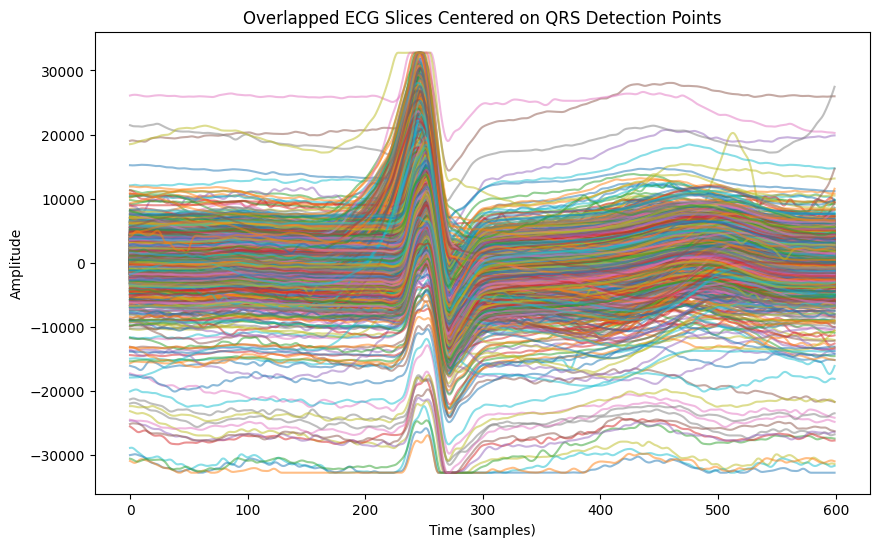

In [215]:
plt.figure(figsize=(10, 6))

for slice_segment in heartbeats:
    plt.plot(slice_segment, alpha=0.5)  
plt.title("Overlapped ECG Slices Centered on QRS Detection Points")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude")
plt.show()

Latidos superpuestos luego de aplicar un detrend y normalizar su amplitud

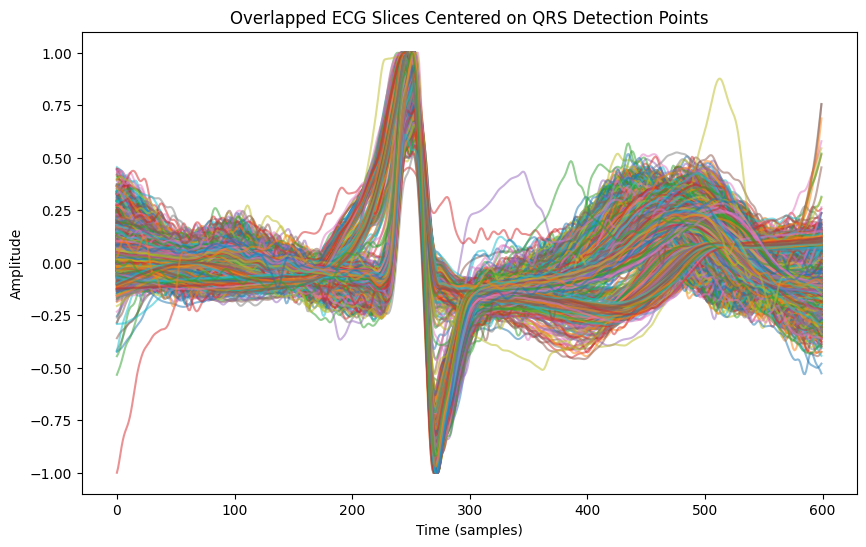

In [216]:
plt.figure(figsize=(10, 6))

for slice_segment in heartbeats_dt:
    plt.plot(slice_segment, alpha=0.5) 
plt.title("Overlapped ECG Slices Centered on QRS Detection Points")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude")
plt.show()

Amplitud promedio de latido

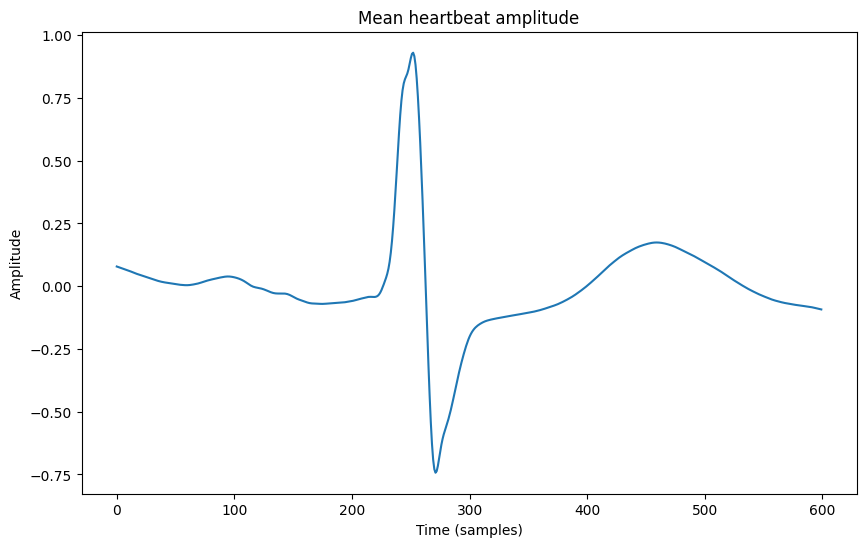

In [217]:
plt.figure(figsize=(10, 6))

mean_hb = np.mean(heartbeats_dt, axis=0)
plt.plot(mean_hb)
plt.title("Mean heartbeat amplitude")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude")
plt.show()


PSD de los primeros 10 segundos con el método de welch

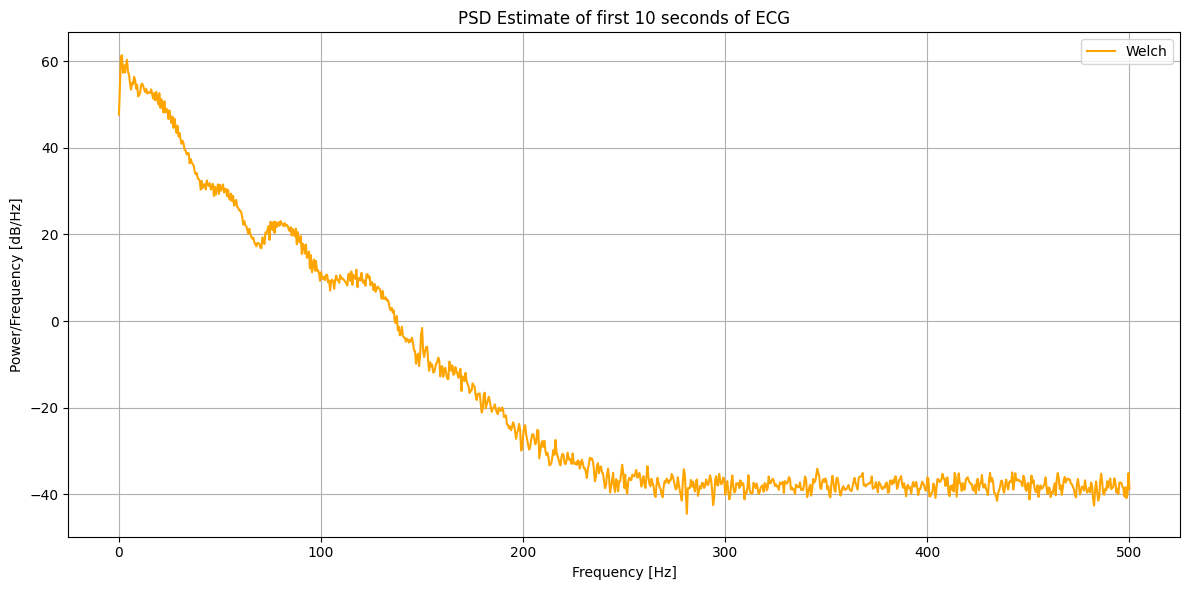

In [218]:
N = 10000
ecg_first_10 = ecg_lead[:N]
fs = 1000
w = 5

f_ecg_10, Pxx_ecg_10 = sig.welch(ecg_first_10, fs, nperseg=int(N/w))

plt.figure(figsize=(12, 6))

plt.plot(f_ecg_10,  10*np.log10(Pxx_ecg_10), label="Welch", color="orange")

plt.title("PSD Estimate of first 10 seconds of ECG")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Power/Frequency [dB/Hz]")

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [219]:
heartbeats_dt = np.array(heartbeats_dt)
heartbeats_dt.shape

(1903, 600)

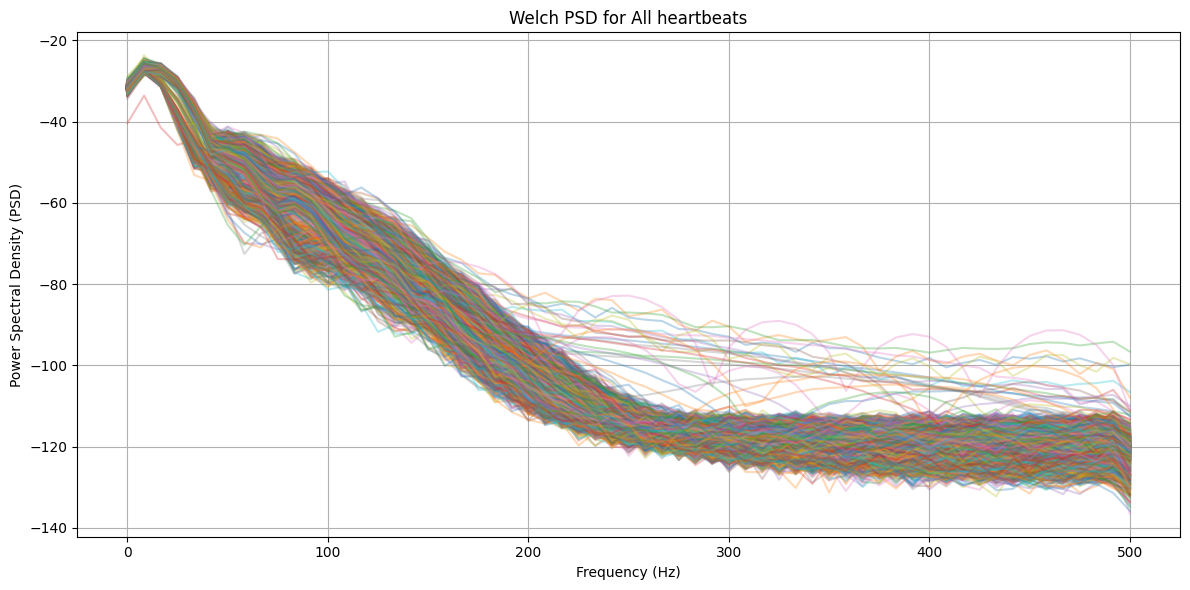

In [220]:
N = heartbeats_dt.shape[1]
plt.figure(figsize=(12, 6))

for i in range(heartbeats_dt.shape[0]):
    signal = heartbeats_dt[i]
    f, Pxx = sig.welch(signal, fs=fs, nperseg=int(N/w))  
    plt.plot(f, 10*np.log10(Pxx), alpha=0.3)  

# Customize the plot
plt.title("Welch PSD for All heartbeats")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (PSD)")
plt.grid(True)
plt.tight_layout()

plt.show()

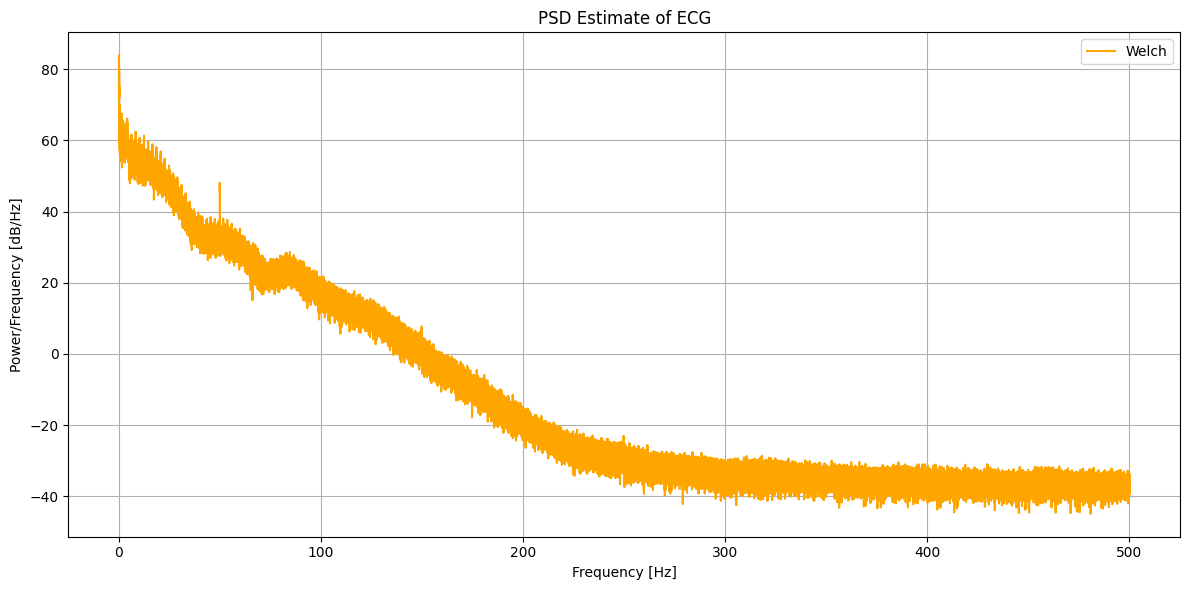

In [221]:

N = len(ecg_lead)

f_ecg, Pxx_ecg = sig.welch(ecg_lead, fs, nperseg=int(N/w))

plt.figure(figsize=(12, 6))

plt.plot(f_ecg,  10*np.log10(Pxx_ecg), label="Welch", color="orange")

plt.title("PSD Estimate of ECG")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Power/Frequency [dB/Hz]")

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

En el espetro total de la señal podemos observar algunas interferencias que no vemos al observar solo los primeros 10 segundos 

In [222]:
hz_100 = (len(f_ecg) // 500) * 100
hz_51 = (len(f_ecg) // 500) * 51
hz_49 = (len(f_ecg) // 500) * 49


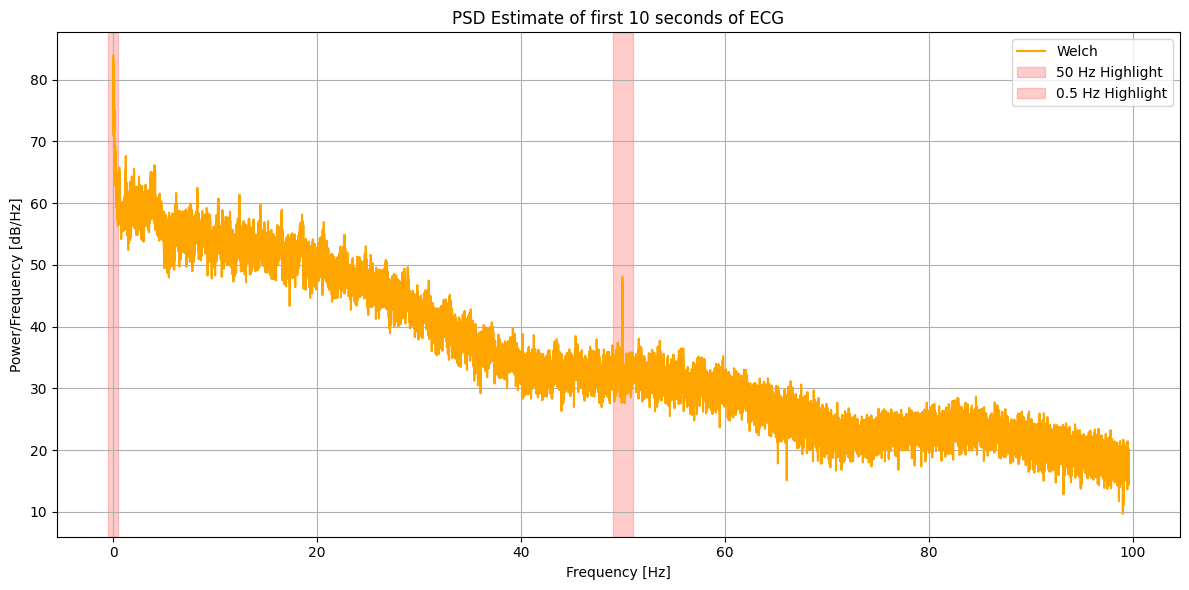

In [225]:

plt.figure(figsize=(12, 6))

plt.plot(f_ecg[:hz_100],  10*np.log10(Pxx_ecg[:hz_100]), label="Welch", color="orange")

plt.title("PSD Estimate of first 10 seconds of ECG")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Power/Frequency [dB/Hz]")
plt.axvspan(49, 51, color='red', alpha=0.2, label="50 Hz Highlight")  # Shaded region
plt.axvspan(-0.5, 0.5, color='red', alpha=0.2, label="0.5 Hz Highlight")  # Shaded region


plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

En base al ancho de banda estimado en el TP7 de 30hz y a los picos de interferencias que podemos ver en 50hz y cerca de los 0hz proponemos esta plantilla para filtrar
#       freq   - att
# ws1 = 0.1 Hz - 40db
# wp1 = 0.5 Hz - 0.5db
# wp2 = 30 Hz  - 0.5db 
# ws2 = 45 Hz  - 40db